<a href="https://colab.research.google.com/github/EdisonVazquezG/DeepLearning_Bourbaki/blob/main/Transformers_Series_de_tiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
import math
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Dataset: Facebook/Meta intradía (1 minuto) — OHLCV + señales de backtest

Este dataset contiene datos de **trading intradía por minuto** para la acción de **Facebook (hoy Meta; ticker histórico: FB)**. Incluye **velas OHLCV** y columnas típicas de **indicadores / señales / resultados de backtesting**.

---

### Columnas principales (mercado)

- **date**: fecha (ej. `2019-04-01`).
- **minute / label**: hora del minuto (ej. `09:30`, `09:31`); `label` suele ser la versión en texto tipo `09:30 AM`.
- **open, high, low, close**: precios de la vela de **ese minuto**.
  - Ej. fila 0 (`09:30`):  
    - open = `167.925`  
    - high = `168.000`  
    - low  = `167.520`  
    - close= `167.820`
- **average**: precio promedio del minuto (puede ser típico, VWAP del minuto o promedio simple; depende de cómo se construyó).
- **volume**: volumen transado (número de acciones) en ese minuto.
- **notional**: volumen en dinero (aprox. `average * volume` o `close * volume`, según definición).

---

### Indicadores y columnas de estrategia (backtest)

- **rsi**: RSI (Relative Strength Index).
  - Al inicio puede aparecer **NaN** porque requiere una ventana previa para calcularse.
  - Un **RSI=100** al principio puede suceder por el “warm-up” o si hubo subidas consecutivas en una ventana corta.
- **long / short**: señal de entrada (abrir posición)  
  - `long` = entrar comprado  
  - `short` = entrar vendido
- **exit_long / exit_short**: señal o precio de salida de la posición (según implementación).
- **long_pnl / short_pnl**: ganancia/pérdida por operaciones long o short.
- **total_pnl**: PnL total (suma de `long_pnl + short_pnl`).
- **long_labels / short_labels**: etiquetas auxiliares (ej. tipo de señal, take-profit/stop, etc.).  
  - Si no hubo trades aún, pueden aparecer como **NaN**.

---

### Nota rápida
En tu snippet inicial, `total_pnl = 0.0` y los labels están en `NaN`, lo que sugiere que **todavía no se activan trades** en esas primeras filas.

In [5]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/facebook.csv")


In [11]:
df.head()

,date,minute,label,high,low,open,close,average,volume,notional,...,rsi,long,exit_long,short,exit_short,long_pnl,short_pnl,total_pnl,long_labels,short_labels
0,2019-04-01,09:30,09:30 AM,168.000,167.52,167.925,167.82,167.775,9294.0,1559300.720,...,NaN,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
1,2019-04-01,09:31,09:31 AM,168.190,167.76,167.760,168.19,167.908,863.0,144904.500,...,100.000000,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
2,2019-04-01,09:32,09:32 AM,168.630,168.36,168.390,168.36,168.490,2707.0,456101.680,...,100.000000,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
3,2019-04-01,09:33,09:33 AM,168.135,167.94,168.135,168.04,168.132,5503.0,925229.920,...,46.468401,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
4,2019-04-01,09:34,09:34 AM,168.200,168.00,168.045,168.01,168.189,15236.0,2562520.845,...,43.215212,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN


## Ventanas y batch size (para series de tiempo)

- **`input_window = 10`**  
  Usas **10 pasos pasados** como entrada para predecir el futuro.  
  En tu dataset de 1 minuto, eso equivale a **10 minutos de historial**.

- **`output_window = 1`**  
  Predices **1 paso hacia adelante**.  
  Con datos por minuto: **predecir el minuto siguiente** (t+1).  
  > Como dices que “es fijo a uno”, tu modelo está configurado como *one-step forecast*.

- **`batch_size = 250`**  
  En cada actualización del entrenamiento, el modelo procesa **250 secuencias** (cada secuencia es una ventana de 10 pasos) antes de hacer un paso de gradiente.

---

### Cómo se ve una muestra (conceptual)
Si la serie es `x[t]`:

- **Entrada (X):** `[x[t-9], x[t-8], ..., x[t]]`  (10 valores)
- **Salida (y):** `x[t+1]`  (1 valor)

---

### Cuántas muestras genera (si tienes N puntos)
Con stride = 1 (ventanas corridas 1 a 1), típicamente:

$$
\begin{aligned}
\text{n_samples} &= N - \text{input_window} - \text{output_window} + 1 \\
&= N - 10 - 1 + 1 \\
&= N - 10
\end{aligned}
$$
(Esto puede variar si usas otro stride o si filtras por sesión/fecha.)

In [6]:
input_window = 10 # number of input steps
output_window = 1 # number of prediction steps, in this model its fixed to one
batch_size = 250

## Qué hace este bloque (logarithmic normalization)

La idea es transformar precios \(p_t\) a **log-retornos**:

$$ r_t = \log(p_t) - \log(p_{t-1}) = \log\left(\frac{p_t}{p_{t-1}}\right) $$

Esto es útil porque:
- Los retornos suelen ser más “estables” que los precios (menos tendencia).
- Facilitan el modelado (menos escala, más simetría en cambios relativos).

Luego haces una suma acumulada:

$$
\sum_{i=1}^t r_i = \log(p_t) - \log(p_0)
$$

O sea, **la cumsum de log-retornos es el log-precio relativo al inicio** (hasta una constante).

In [8]:
# logarithmic normalization
open = df["open"].fillna(method="ffill")
open = np.array(open)
open_logreturn = np.diff(np.log(open))
open_csum_logreturn = open_logreturn.cumsum()


close = df["close"].fillna(method="ffill")
close = np.array(close)
close_logreturn = np.diff(np.log(close))
close_csum_logreturn = close_logreturn.cumsum()


average = df["average"].fillna(method="ffill")
average = np.array(average)
average_logreturn = np.diff(np.log(average))
average_csum_logreturn = average_logreturn.cumsum()

/tmp/ipykernel_598/2445134955.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  open = df["open"].fillna(method="ffill")
/tmp/ipykernel_598/2445134955.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close = df["close"].fillna(method="ffill")
/tmp/ipykernel_598/2445134955.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  average = df["average"].fillna(method="ffill")
/tmp/ipykernel_598/2445134955.py:16: RuntimeWarning: invalid value encountered in log
  average_logreturn = np.diff(np.log(average))


Text(0, 0.5, 'average Price')

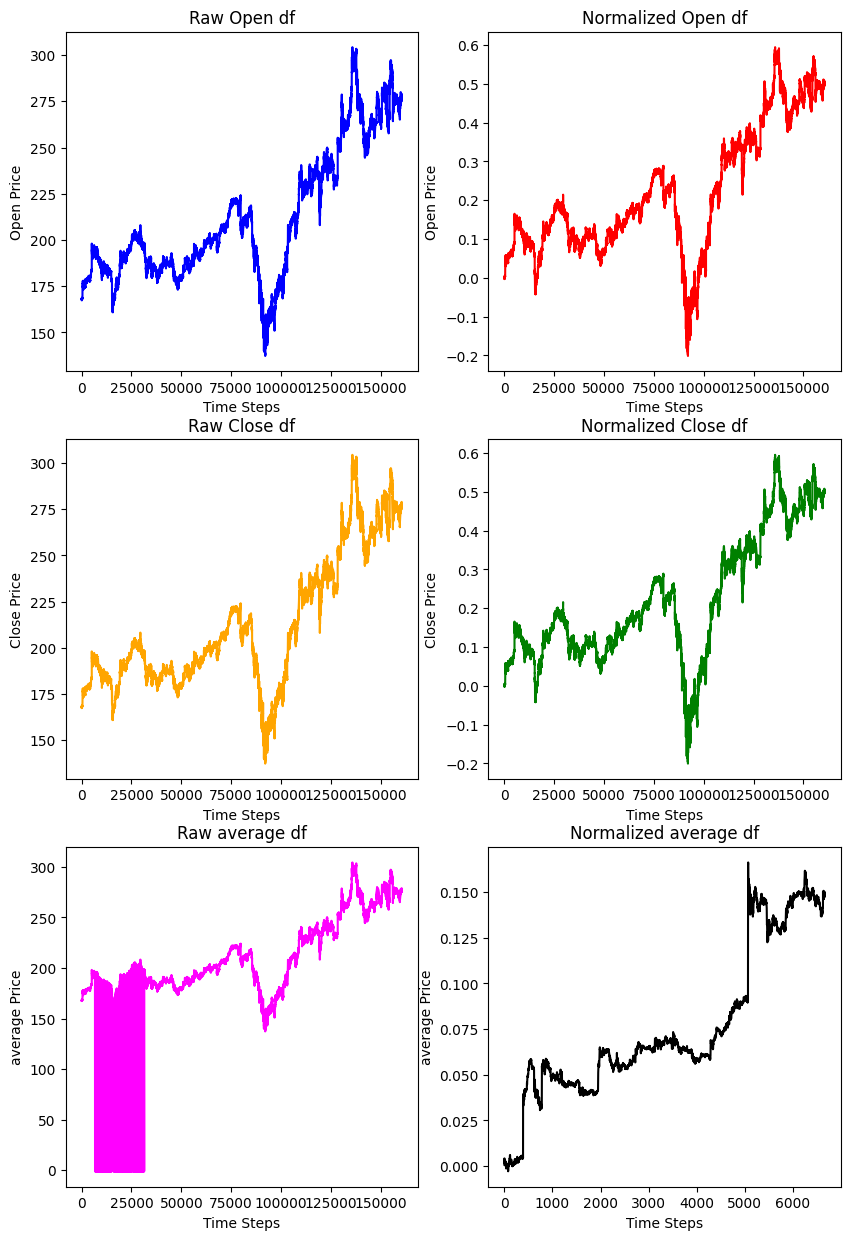

In [9]:
fig = plt.figure(figsize=(10, 15))

plt.subplot(3, 2, 1)
plt.plot(open, color="blue")
plt.title("Raw Open df")
plt.xlabel("Time Steps")
plt.ylabel("Open Price")

plt.subplot(3, 2, 2)
plt.plot(open_csum_logreturn, color="red")
plt.title("Normalized Open df")
plt.xlabel("Time Steps")
plt.ylabel("Open Price")

plt.subplot(3, 2, 3)
plt.plot(close, color="orange")
plt.title("Raw Close df")
plt.xlabel("Time Steps")
plt.ylabel("Close Price")

plt.subplot(3, 2, 4)
plt.plot(close_csum_logreturn, color="green")
plt.title("Normalized Close df")
plt.xlabel("Time Steps")
plt.ylabel("Close Price")

plt.subplot(3, 2, 5)
plt.plot(average, color="magenta")
plt.title("Raw average df")
plt.xlabel("Time Steps")
plt.ylabel("average Price")

plt.subplot(3, 2, 6)
plt.plot(average_csum_logreturn, color="black")
plt.title("Normalized average df")
plt.xlabel("Time Steps")
plt.ylabel("average Price")

## 2. Model Definition

### 2.1. Positional Encoding Layer

En un Transformer, la atención **no “sabe” el orden** de la secuencia por sí sola.  
Por eso se añade *positional encoding*: un vector que depende de la posición temporal \(t\), y se **suma** a los embeddings de entrada.

La versión sinusoidal usa senos y cosenos con distintas frecuencias:

- Dimensiones pares: $$ sin(\cdot) $$
- Dimensiones impares:$$ cos(\cdot) $$

Esto permite que el modelo:
- distinga posiciones (t=0 vs t=1 vs t=2…)
- aprenda relaciones de distancia relativa entre pasos (por patrones periódicos)


In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]

## 2.2. Transformer Model

Esta clase define un **Transformer Encoder** para series de tiempo. La idea general es:

1. Recibir una secuencia de longitud `seq_len` (por ejemplo `input_window=10`).
2. Añadir **información de posición** (positional encoding).
3. Procesar la secuencia con **self-attention** (TransformerEncoder).
4. Convertir cada vector interno (`feature_size`) a una predicción escalar con una capa lineal.

> **Formato de entrada esperado**
>
> Este modelo asume que `src` tiene shape:
> $$
> \texttt{src} \in \mathbb{R}^{(\text{seq_len}, \text{batch}, \text{feature_size})}
> $$
> Es decir: **(tiempo, batch, features)**.


In [12]:
class transformer(nn.Module):
    def __init__(self, feature_size=250, num_layers=1, dropout=0.1):
        super(transformer, self).__init__()
        self.model_type = "Transformer"

        self.src_mask = None
        self.pos_encoder = PositionalEncoding(feature_size)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=feature_size, nhead=10, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(feature_size,1)
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self,src):
        if(self.src_mask is None or self.src_mask.size(0) != len(src)):
            device = src.device
            mask = self._generate_square_subsequent_mask(len(src)).to(device)
            self.src_mask = mask

        src = self.pos_encoder(src)
        output = self.transformer_encoder(src,self.src_mask)
        output = self.decoder(output)
        return output

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float("-inf")).masked_fill(mask == 1, float(0.0))
        return mask

## 3. Utils Functions — explicación (ventanas, split, batches)

Estas funciones preparan tu serie de tiempo para el Transformer en tres pasos:

1) Crear pares **(input_window → label_window)** con ventanas deslizantes.  
2) Separar en **train/test** y aplicar transformaciones (cumsum, scaling).  
3) Empaquetar ventanas en **batches** con el shape esperado por el Transformer.


In [1]:
def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+output_window:i+tw+output_window]
        inout_seq.append((train_seq ,train_label))
    return torch.FloatTensor(inout_seq)

In [2]:
def get_data(data, split):

    series = data

    split = round(split * len(series))
    train_data = series[:split]
    test_data = series[split:]

    train_data = train_data.cumsum()

    # Training data augmentation, increase amplitude for the model to better generalize.(Scaling by 2 is aribitrary)
    # Similar to image transformation to allow model to train on wider data sets
    train_data = 2 * train_data

    test_data = test_data.cumsum()

    train_sequence = create_inout_sequences(train_data, input_window)
    train_sequence = train_sequence[:-output_window]

    test_data = create_inout_sequences(test_data, input_window)
    test_data = test_data[:-output_window]

    return train_sequence.to(device), test_data.to(device)

In [3]:
def get_batch(source, i, batch_size):
    seq_len = min(batch_size, len(source) - 1 - i)
    data = source[i:i+seq_len]
    input = torch.stack(torch.stack([item[0] for item in data]).chunk(input_window, 1))
    target = torch.stack(torch.stack([item[1] for item in data]).chunk(input_window, 1))
    return input, target

## Función `train(train_data)`

Esta función ejecuta **una época (epoch)** de entrenamiento:

- toma los datos en ventanas (`train_data`)
- los divide en batches
- hace forward → loss → backward → actualización de pesos
- imprime métricas cada cierto número de batches


In [4]:
def train(train_data):
    model.train()
    total_loss = 0.0
    start_time = time.time()

    for batch, i in enumerate(range(0, len(train_data) - 1, batch_size)):
        data, targets = get_batch(train_data, i,batch_size)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.7)
        optimizer.step()

        total_loss += loss.item()
        log_interval = int(len(train_data) / batch_size / 5)
        if(batch % log_interval == 0 and batch > 0):
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            print("| epoch {:3d} | {:5d}/{:5d} batches | "
                  "lr {:02.10f} | {:5.2f} ms | "
                  "loss {:5.7f}".format(
                    epoch, batch, len(train_data) // batch_size, scheduler.get_lr()[0],
                    elapsed * 1000 / log_interval,
                    cur_loss))
            total_loss = 0
            start_time = time.time()

In [5]:
def evaluate(eval_model, data_source):
    eval_model.eval()
    total_loss = 0.0
    eval_batch_size = 1000
    with torch.no_grad():
        for i in range(0, len(data_source) - 1, eval_batch_size):
            data, targets = get_batch(data_source, i, eval_batch_size)
            output = eval_model(data)
            total_loss += len(data[0])* criterion(output, targets).cpu().item()
    return total_loss / len(data_source)

## 3.6. Forecast Function — explicación (predicción)

Aquí tienes dos funciones de predicción:

- **3.6.1 `model_forecast`**: genera predicción a partir de **una ventana** (y puede extenderla iterativamente).
- **3.6.2 `forecast_seq`**: recorre **todas las ventanas** del dataset y compara predicción vs real.

---

# 3.6.1. `model_forecast(model, seqence)`  
### (predicción desde una ventana; 1-step o autoregresivo)


In [7]:
#3.6.1. for one time step from window sequence
def model_forecast(model, seqence):
    model.eval()
    total_loss = 0.0
    test_result = torch.Tensor(0)
    truth = torch.Tensor(0)

    seq = np.pad(seqence, (0, 3), mode="constant", constant_values=(0, 0))
    seq = create_inout_sequences(seq, input_window)
    seq = seq[:-output_window].to(device)

    seq, _ = get_batch(seq, 0, 1)
    with torch.no_grad():
        for i in range(0, output_window):
            output = model(seq[-output_window:])
            seq = torch.cat((seq, output[-1:]))

    seq = seq.cpu().view(-1).numpy()

    return seq

In [8]:
#3.6.2. for entire sequence
def forecast_seq(model, sequences):

    start_timer = time.time()
    model.eval()
    forecast_seq = torch.Tensor(0)
    actual = torch.Tensor(0)
    with torch.no_grad():
        for i in range(0, len(sequences) - 1):
            data, target = get_batch(sequences, i, 1)
            output = model(data)
            forecast_seq = torch.cat((forecast_seq, output[-1].view(-1).cpu()), 0)
            actual = torch.cat((actual, target[-1].view(-1).cpu()), 0)
    timed = time.time()-start_timer
    print(f"{timed} sec")

    return forecast_seq, actual

## 4. Fase de entrenamiento

In [ ]:
train_data, val_data = get_data(close_logreturn, 0.6) # 60% train, 40% test split
model = transformer().to(device)

criterion = nn.MSELoss()
lr = 0.00005
epochs = 200

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(train_data)

    if(epoch % epochs == 0): # Valid model after last training epoch
        val_loss = evaluate(model, val_data)
        print("-" * 80)
        print("| end of epoch {:3d} | time: {:5.2f}s | valid loss: {:5.7f}".format(epoch, (time.time() - epoch_start_time), val_loss))
        print("-" * 80)

    else:
        print("-" * 80)
        print("| end of epoch {:3d} | time: {:5.2f}s".format(epoch, (time.time() - epoch_start_time)))
        print("-" * 80)

    scheduler.step()

In [ ]:
test_result, truth = forecast_seq(model, val_data)

## 5. Resultados

In [ ]:
#Plot forecasted sequence vs actual
plt.plot(truth, color="red", alpha=0.7)
plt.plot(test_result, color="blue", linestyle="dashed", linewidth=0.7)
plt.title("Actual vs Forecast")
plt.legend(["Actual", "Forecast"])
plt.xlabel("Time Steps")
plt.show()

## 6. Validación

In [1]:
model_val = transformer()
model_val.load_state_dict(torch.load("model/time_forecasting_transformer.pth"))
model_val.to(device)

NameError: name 'transformer' is not defined

## 7. Otros datos

In [4]:
df2 = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/boeing.csv")
close2 = df2["close"].fillna(method = "ffill")
close2 = np.array(close2)
logreturn2 = np.diff(np.log(close2))

/tmp/ipykernel_598/2847754109.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close2 = df2["close"].fillna(method = "ffill")


In [ ]:
train_data2, val_data2 = get_data(logreturn2, 0.6)
test2_eval = evaluate(model_val, val_data2)
print(f"boeing test loss: {test2_eval :.5f}")

In [ ]:
test_result2, truth2 = forecast_seq(model_val, val_data2)

plt.plot(truth2, color="red", alpha=0.7)
plt.plot(test_result2, color="blue", linestyle="dashed", linewidth=0.7)
plt.title("Actual vs Forecast")
plt.legend(["Actual", "Forecast"])
plt.xlabel("Time Steps")
plt.show()